In [190]:
# !pip install missingno
# !pip install geopy

In [191]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import missingno as msno
sns.set()
plt.style.use('ggplot')
import warnings

# Ignore warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [192]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [193]:
df_EDA = pd.read_pickle('/content/drive/My Drive/Airbnb/df_EDA.pkl')

In [194]:
df = df_EDA.copy()

In [195]:
# df = df.drop(columns=['Listing ID','Host ID'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23536 entries, 0 to 23535
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Listing ID             23536 non-null  int64  
 1   Accomodates            23536 non-null  float64
 2   Accuracy Rating        18888 non-null  float64
 3   Bathrooms              23507 non-null  float64
 4   Bedrooms               23516 non-null  float64
 5   Beds                   23501 non-null  float64
 6   Checkin Rating         18870 non-null  float64
 7   Cleanliness Rating     18892 non-null  float64
 8   Communication Rating   18886 non-null  float64
 9   Guests Included        23536 non-null  float64
 10  Host Response Rate     13046 non-null  float64
 11  Latitude               23536 non-null  float64
 12  Location Rating        18871 non-null  float64
 13  Longitude              23536 non-null  float64
 14  Min Nights             23536 non-null  float64
 15  Ov

## Defines data columns Lists

In [196]:
numerical_columns = ['Price','Accomodates', 'Bathrooms', 'Bedrooms', 'Beds', 'Guests Included','Min Nights','Reviews']
rating_columns = ['Value Rating','Location Rating', 'Cleanliness Rating','Checkin Rating','Accuracy Rating','Communication Rating','Host Response Rate','Overall Rating']
boolean_columns = ['Is Superhost','Is Exact Location', 'Instant Bookable']
categorical_columns = ['Room Type','Property Type Reduced','Neighborhood Group','Postal Code Reduced','Host Response Time']
date_columns = ['review_date','Host Since']
non_categorical_columns = numerical_columns + rating_columns + boolean_columns

# EDA - Explenatory Data Analysis

In [197]:
df.head(2)

,Listing ID,Accomodates,Accuracy Rating,Bathrooms,Bedrooms,Beds,Checkin Rating,Cleanliness Rating,Communication Rating,Guests Included,Host Response Rate,Latitude,Location Rating,Longitude,Min Nights,Overall Rating,Price,Reviews,Value Rating,review_date,Comments,Host Since,Host Response Time,Is Superhost,neighbourhood,Neighborhood Group,Postal Code,Is Exact Location,Property Type,Room Type,Instant Bookable,Neighbourhood Grouped,Property Type Reduced,Postal Code Reduced
0,2695,2.0,10.0,1.0,1.0,1.0,10.0,10.0,10.0,1.0,50.0,52.54851,9.0,13.40455,2.0,100.0,17.0,7.0,10.0,07-04-18,I really enjoyed staying at Micha and Nadja's ...,09-16-08,within a day,False,Prenzlauer Berg,Pankow,10437,True,Apartment,Private room,False,Pankow,Apartment,10
1,3176,4.0,9.0,1.0,1.0,2.0,9.0,9.0,9.0,2.0,50.0,52.53500,10.0,13.41758,62.0,92.0,90.0,144.0,9.0,06-20-09,"excellent stay, i would highly recommend it. a...",10-19-08,within a day,False,Prenzlauer Berg,Pankow,10405,True,Apartment,Entire home/apt,False,Pankow,Apartment,10


## Data Protocol

In [198]:
#Type of data
df.dtypes.to_excel ("df_datatype.xlsx", sheet_name='data_types')

#Maximum points
df[non_categorical_columns].max().to_excel("df_max.xlsx", sheet_name='max')

#Minimum points
df[non_categorical_columns].max().to_excel("df_max.xlsx", sheet_name='min')

#Isnull values
df.isnull().to_excel("df_isnull.xlsx", sheet_name='isnull')

#unique values
df.nunique().to_excel("df_nunique.xlsx", sheet_name='nunique')

# Categorical values
df[categorical_columns].describe().to_excel("df_categorical.xlsx", sheet_name='categorical')

## Descriptive statistics
   

In [199]:
df.shape

(23536, 34)

In [200]:
df[numerical_columns].describe()

,Price,Accomodates,Bathrooms,Bedrooms,Beds,Guests Included,Min Nights,Reviews
count,23536.000000,23536.000000,23507.000000,23516.000000,23501.000000,23536.000000,23536.000000,23536.000000
mean,69.612424,2.671737,1.095971,1.161720,1.641802,1.346151,6.897774,19.238826
std,216.660408,1.567812,0.346150,0.660736,1.228642,0.856297,24.879032,40.360483
min,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,32.000000,2.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000
50%,49.000000,2.000000,1.000000,1.000000,1.000000,1.000000,3.000000,5.000000
75%,75.000000,3.000000,1.000000,1.000000,2.000000,1.000000,4.000000,17.000000
max,9000.000000,16.000000,8.500000,10.000000,22.000000,16.000000,1000.000000,545.000000


In [201]:
df[rating_columns].describe()

,Value Rating,Location Rating,Cleanliness Rating,Checkin Rating,Accuracy Rating,Communication Rating,Host Response Rate,Overall Rating
count,18868.000000,18871.000000,18892.000000,18870.000000,18888.000000,18886.000000,13046.000000,18914.000000
mean,9.417638,9.550315,9.334904,9.728829,9.679850,9.746479,91.842174,94.564344
std,0.840456,0.748713,1.031248,0.695275,0.737798,0.679600,19.447852,7.599949
min,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,0.000000,20.000000
25%,9.000000,9.000000,9.000000,10.000000,10.000000,10.000000,95.000000,92.000000
50%,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,100.000000,97.000000
75%,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,100.000000,100.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,100.000000,100.000000


In [202]:
df[boolean_columns].describe()

,Is Superhost,Is Exact Location,Instant Bookable
count,23536,23536,23536
unique,2,2,2
top,False,True,False
freq,19969,17649,15658


In [203]:
df[categorical_columns].describe()

,Room Type,Property Type Reduced,Neighborhood Group,Postal Code Reduced,Host Response Time
count,23536,23536,23536,23536,13046
unique,3,15,12,8,4
top,Private room,Apartment,Friedrichshain-Kreuzberg,10,within an hour
freq,11694,20935,5726,14667,6816


In [204]:
# df[['Host Since Year', 'Host Since Month', 'Host Since Day']].describe()

Several rows with unusually high values can be identified and may in some cases be dropped at a certain threshold

The description of price shows that 75% of the room only charged within 70€. But we can find the maximized price is extremely large - up to 9000€.

In [205]:
df[['Beds', 'Min Nights', 'Reviews', 'Price']].describe().loc[['max']].T

,max
Beds,22.0
Min Nights,1000.0
Reviews,545.0
Price,9000.0


## Target Value

In [206]:
df[['Price']].describe()

,Price
count,23536.000000
mean,69.612424
std,216.660408
min,0.000000
25%,32.000000
50%,49.000000
75%,75.000000
max,9000.000000


The description of price shows that 75% of the room only charged within 70€. But we can find the maximized price is extremely large - up to 9000€.

### Distribution of Price

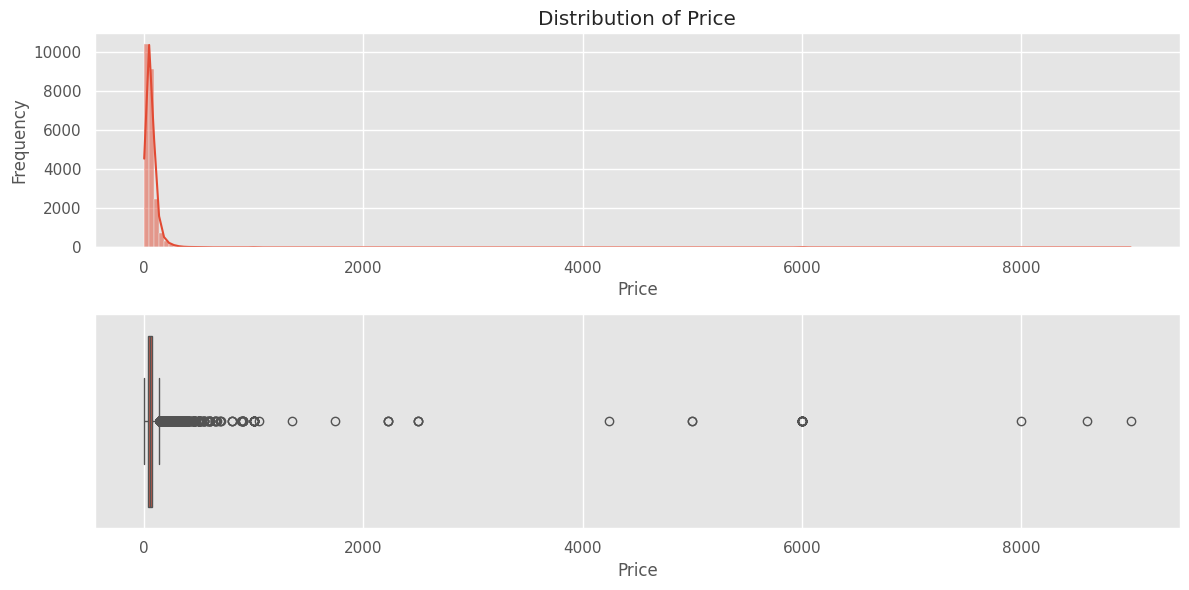

In [207]:
def target_value_distributions(df):
  plt.figure(figsize=(12, 6))
  plt.subplot(2, 1, 1)
  sns.histplot(df['Price'], bins=200, kde=True)
  plt.title("Distribution of Price")
  plt.xlabel("Price")
  plt.ylabel("Frequency")

  plt.subplot(2, 1, 2)
  sns.boxplot(df['Price'], orient='h')
  plt.xlabel("Price")

  plt.tight_layout()
  plt.show()

# Distribution of Price before dropping extream outlier values
target_value_distributions(df)

In [208]:
df = df[(df['Price'] <= 600) & (df['Price'] > 0)]
df['Price'].describe()

,Price
count,23460.000000
mean,60.926726
std,49.445524
min,1.000000
25%,31.000000
50%,49.000000
75%,74.000000
max,600.000000


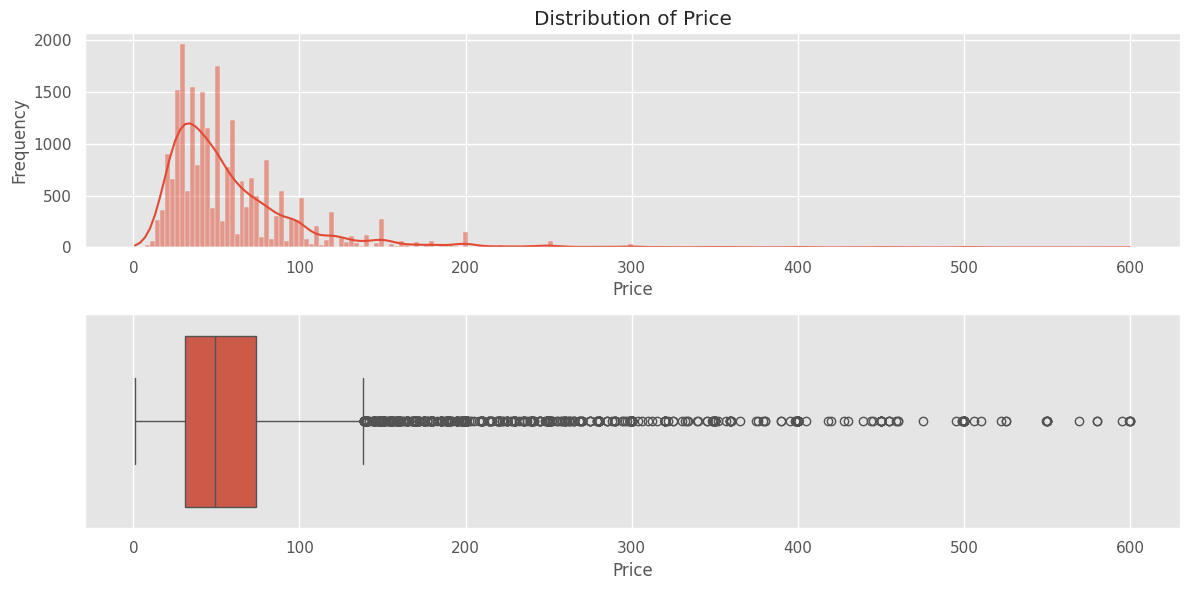

In [209]:
# Distribution of Price
target_value_distributions(df)

### Location vs Price

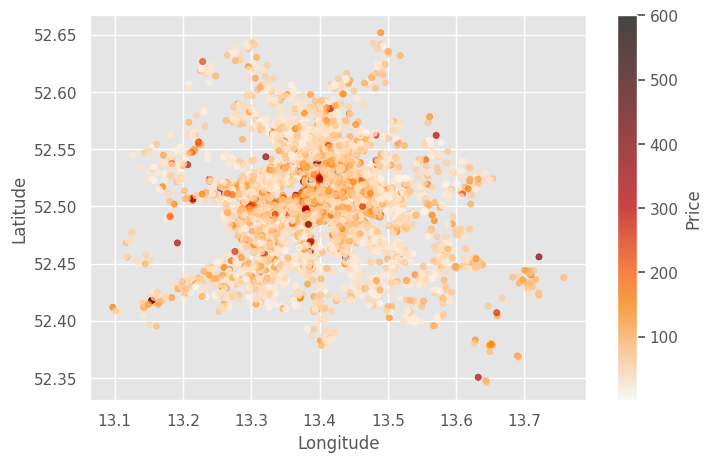

In [210]:
df.plot(kind="scatter", x="Longitude", y="Latitude", alpha=0.7, figsize=(8,5),
        c="Price", cmap="gist_heat_r", colorbar=True, sharex=False);

## Missing values

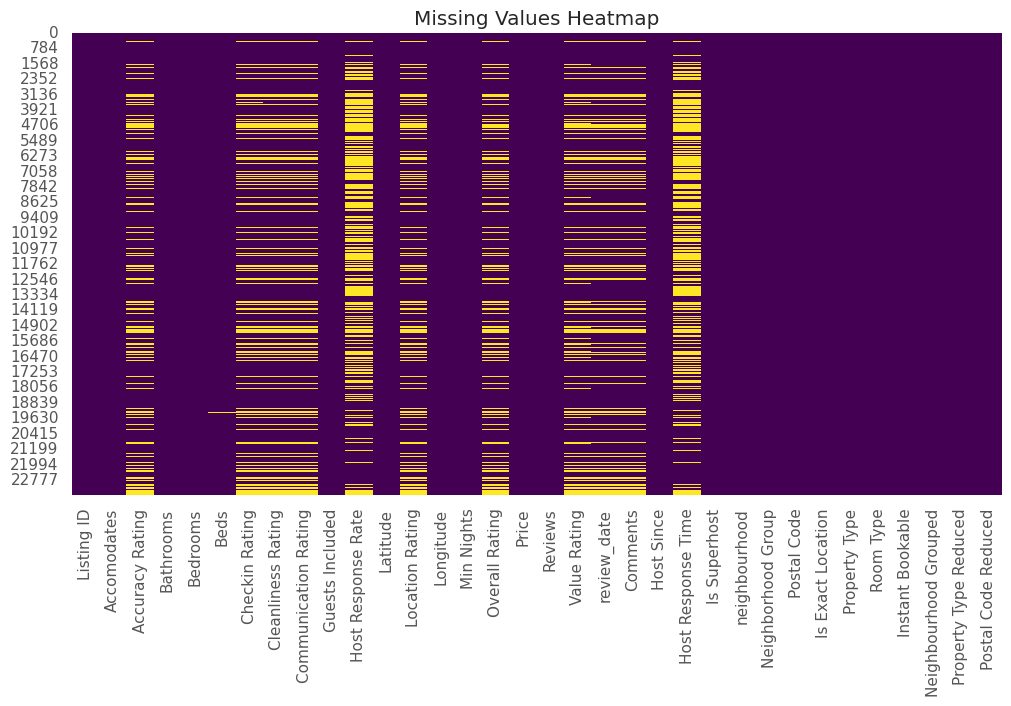

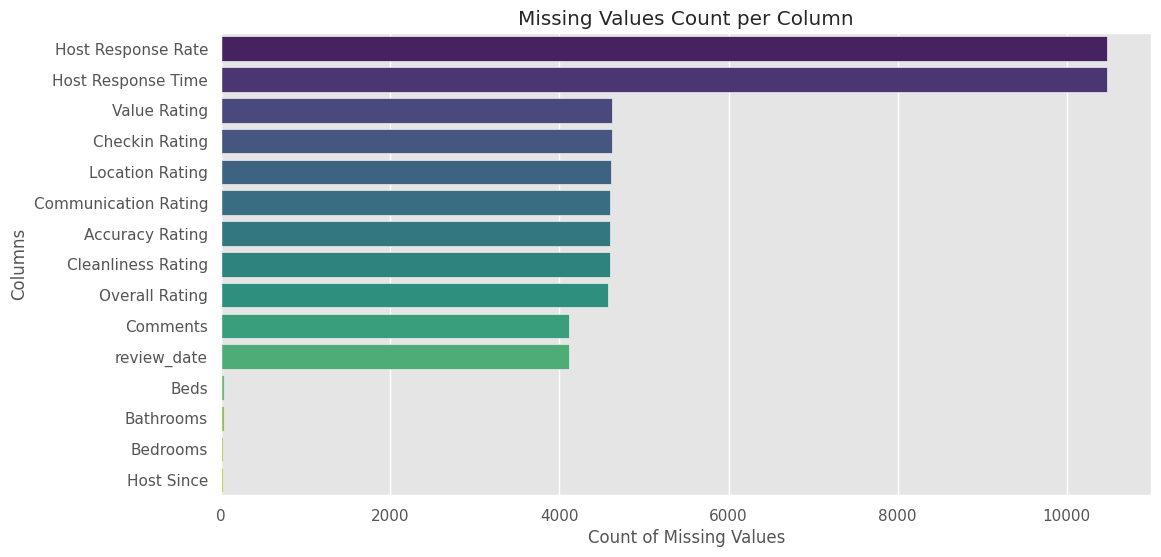


Missing Values:
Host Response Rate      10476
Host Response Time      10476
Value Rating             4618
Checkin Rating           4616
Location Rating          4615
Communication Rating     4600
Accuracy Rating          4598
Cleanliness Rating       4594
Overall Rating           4572
Comments                 4110
review_date              4108
Beds                       34
Bathrooms                  29
Bedrooms                   20
Host Since                 20
dtype: int64


In [211]:
# Check for missing values
missing_values = df.isnull().sum()

# Visualizing missing values
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

# Display missing values as a bar chart
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_values.values, y=missing_values.index, palette="viridis")
plt.xlabel("Count of Missing Values")
plt.ylabel("Columns")
plt.title("Missing Values Count per Column")
plt.show()


print("\nMissing Values:")
print(missing_values)

## Dummies

In [212]:
def plot_counts_for_columns(df, columns_names, rows=1, cols=3, figsize_=(20, 6)):
  i = 1
  plt.figure(figsize=figsize_)
  plt.subplots_adjust(hspace = 0.5)
  for col in columns_names:
    plt.subplot(rows, cols, i)
    plt.title(f"'{col}'")
    plt.xlabel(col)
    plt.ylabel("Count")
    sns.countplot(data=df, x=col, palette="viridis")
    i = i + 1

  plt.tight_layout()
  plt.show()
  print (i)

In [213]:
boolean_columns

['Is Superhost', 'Is Exact Location', 'Instant Bookable']

In [214]:
df['Is Superhost'] = df['Is Superhost'].astype(bool)
df[boolean_columns].info()

<class 'pandas.core.frame.DataFrame'>
Index: 23460 entries, 0 to 23535
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Is Superhost       23460 non-null  bool 
 1   Is Exact Location  23460 non-null  bool 
 2   Instant Bookable   23460 non-null  bool 
dtypes: bool(3)
memory usage: 252.0 KB


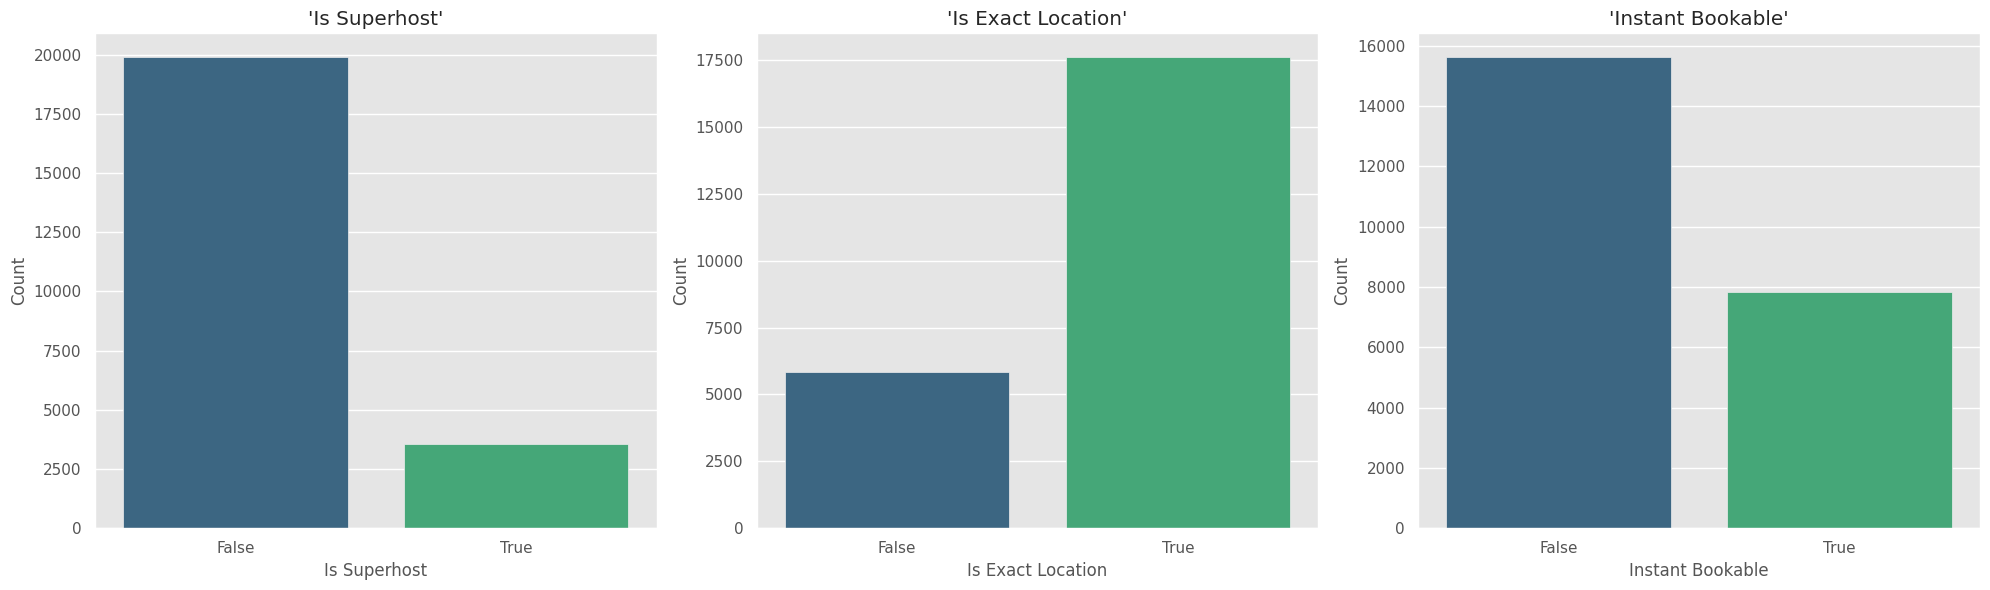

4


In [215]:
plot_counts_for_columns(df, boolean_columns)

## Categorial

In [216]:
df[categorical_columns].describe().T

,count,unique,top,freq
Room Type,23460,3,Private room,11658
Property Type Reduced,23460,15,Apartment,20914
Neighborhood Group,23460,12,Friedrichshain-Kreuzberg,5720
Postal Code Reduced,23460,8,10,14613
Host Response Time,12984,4,within an hour,6780


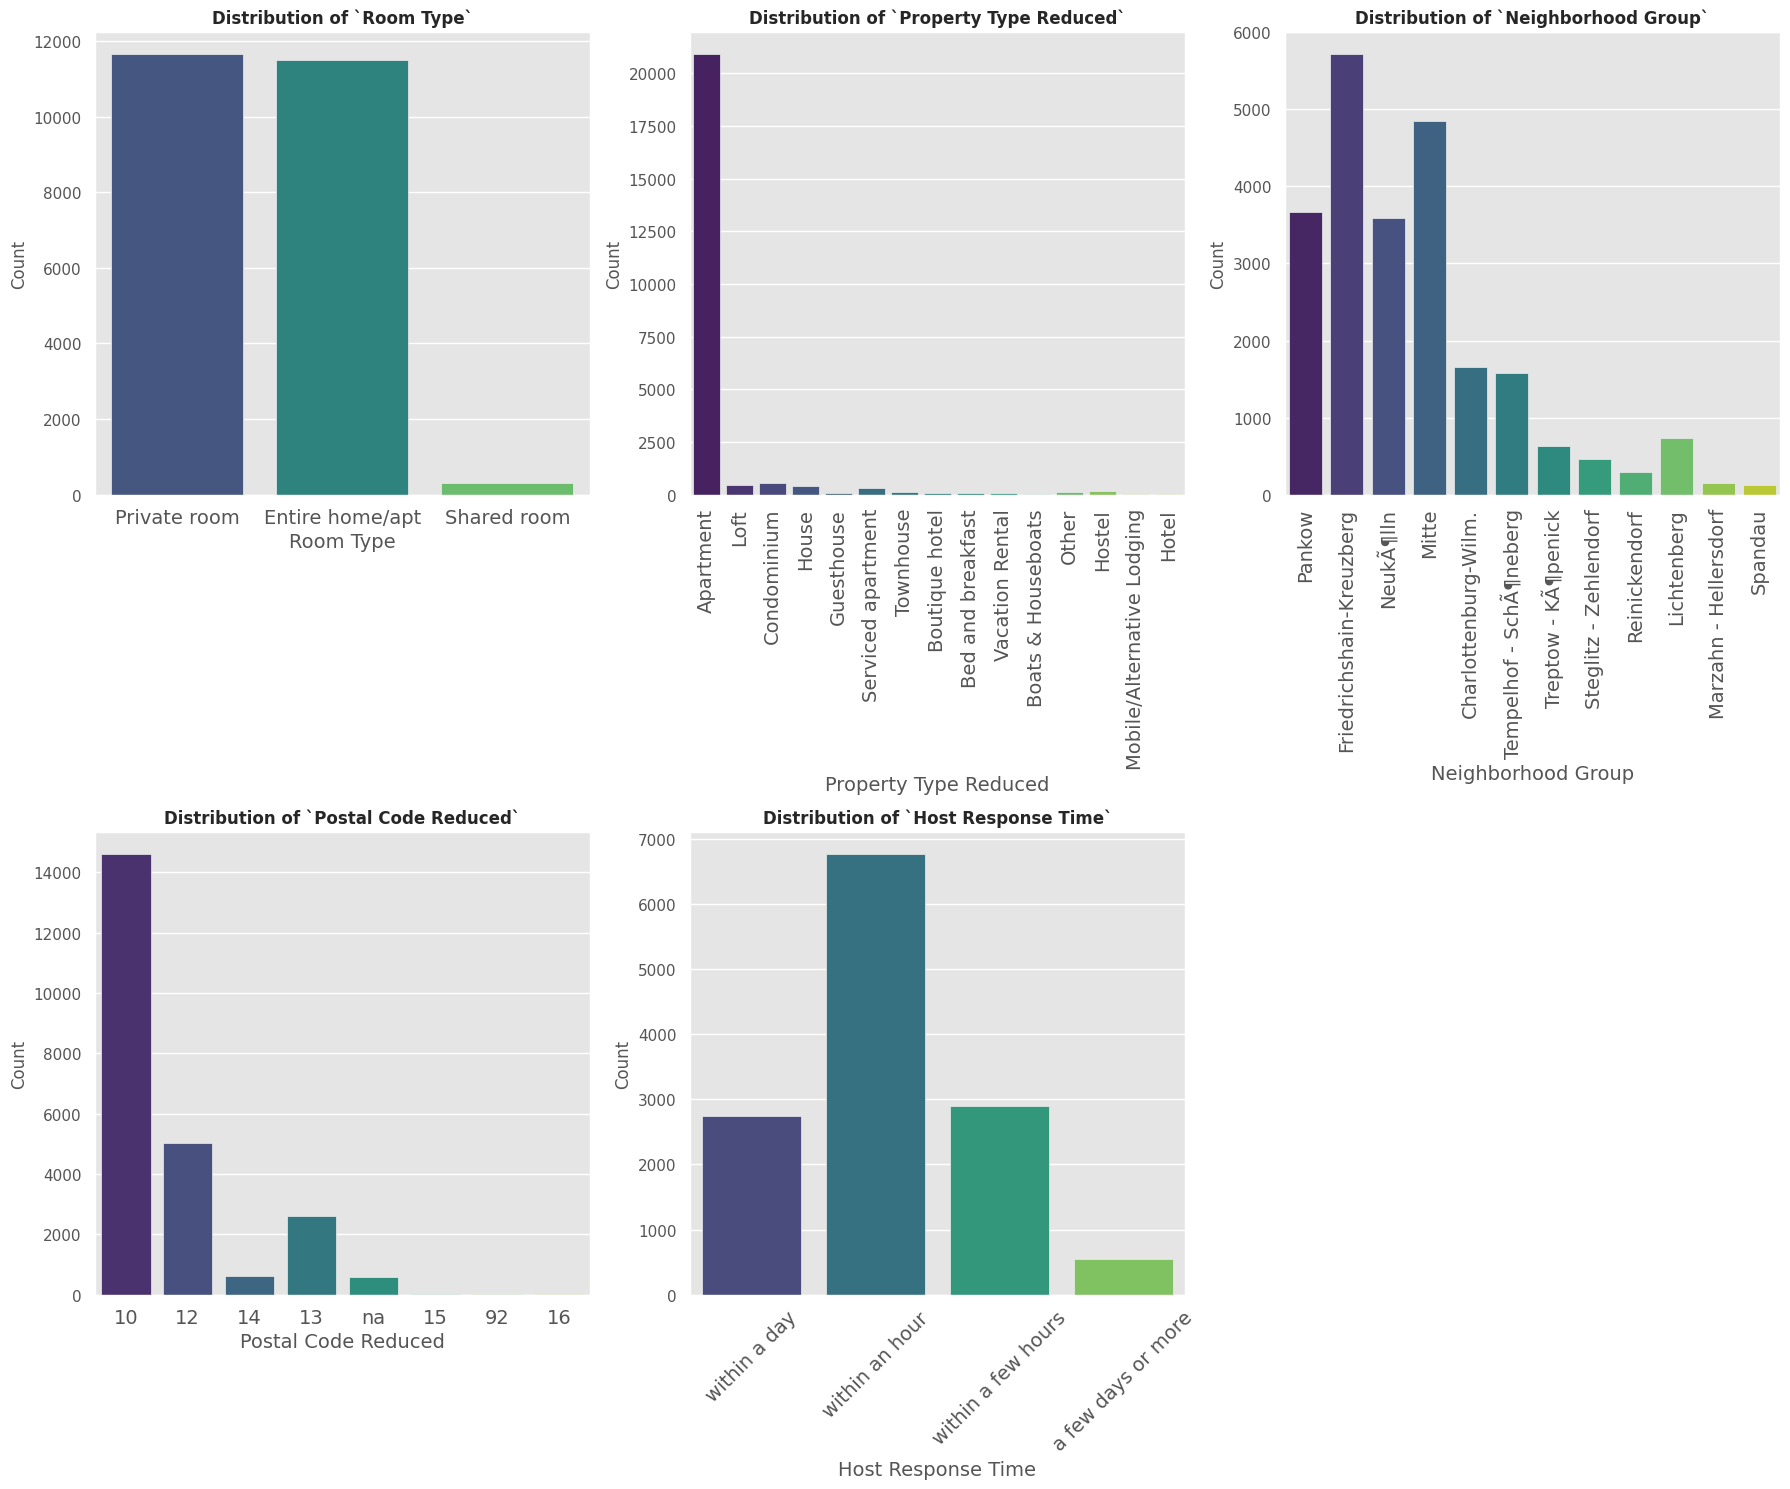

In [217]:
xticks_map = {'Room Type':0, 'Property Type Reduced':90, 'Neighborhood Group':90, 'Neighbourhood Grouped':90, 'Postal Code Reduced':0, 'Host Response Time':45}
i = 1
plt.figure(figsize=(18, 15))
plt.subplots_adjust(hspace = 0.5)
for col in categorical_columns:
  plt.subplot(2, 3, i)
  plt.title(f"Distribution of `{col}`", fontsize=12, fontweight="bold")
  plt.xlabel(col, fontsize=14)
  plt.xticks(rotation=xticks_map.get(col, 0), fontsize=14)
  plt.ylabel("Count")
  sns.countplot(data=df, x=col, palette="viridis")
  i = i + 1

plt.tight_layout()
plt.show()

In [218]:
# df = df_EDA.copy()

In [219]:
# df['Host Since Year'] = df['Host Since Year'].astype('str').apply(lambda x: (x.split('.')[0]))
# df['Host Since Year'] = df['Host Since Year'].apply(lambda x: None if x == 'nan' else x).astype('category')
# df['Host Since Month'] = df['Host Since Month'].astype('str').apply(lambda x: x.split('.')[0])
# df['Host Since Month'] = df['Host Since Month'].apply(lambda x: None if x == 'nan' else x).astype('category')
# df['Host Since Day'] = df['Host Since Day'].astype('str').apply(lambda x: x.split('.')[0])
# df['Host Since Day'] = df['Host Since Day'].apply(lambda x: None if x == 'nan' else x).astype('category')

In [220]:
# df['Host Since Year'].info()

In [221]:
# df['Host Since Year'].isna().sum()

In [222]:
# df['Host Since Month'].value_counts().index.sort_values()
# df['Host Since Month'].value_counts().index.sort_values( key=lambda x: pd.to_numeric(x, errors='coerce'))

In [223]:
# i = 1
# plt.figure(figsize=(15, 8))
# # Adjust spacing
# plt.subplots_adjust(hspace=0.6)
# for col in ['Host Since Year','Host Since Month','Host Since Day']:
#   plt.subplot(2, 2, i)
#   plt.title(f"Distribution of `{col}`", fontsize=10, fontweight="bold")
#   plt.xlabel(col)
#   plt.xticks(rotation=xticks_map.get(col, 0))
#   plt.ylabel("Count")
#   sorted_order = df[col].value_counts().index.sort_values( key=lambda x: pd.to_numeric(x, errors='coerce'))
#   sns.countplot(data=df, x=col, order=sorted_order, palette="viridis")
#   i = i + 1

# plt.tight_layout()
# plt.show()

## Continues and numrical data

### Histograms for continues numbers

Checking the distribution of key numerical features

In [224]:
numerical_columns

['Price',
 'Accomodates',
 'Bathrooms',
 'Bedrooms',
 'Beds',
 'Guests Included',
 'Min Nights',
 'Reviews']

In [225]:
def plot_histplot_for_columns(df, numerical_columns):
  plt.figure(figsize=(12, 12))
  plt.subplots_adjust(hspace = 0.5)
  for i, col in enumerate(numerical_columns, 1):
    plt.subplot(4, 2, i)
    sns.histplot(df[col].dropna(), bins=50, kde=False)
    plt.title(f"Distribution of {col}")

  plt.tight_layout()
  plt.show()

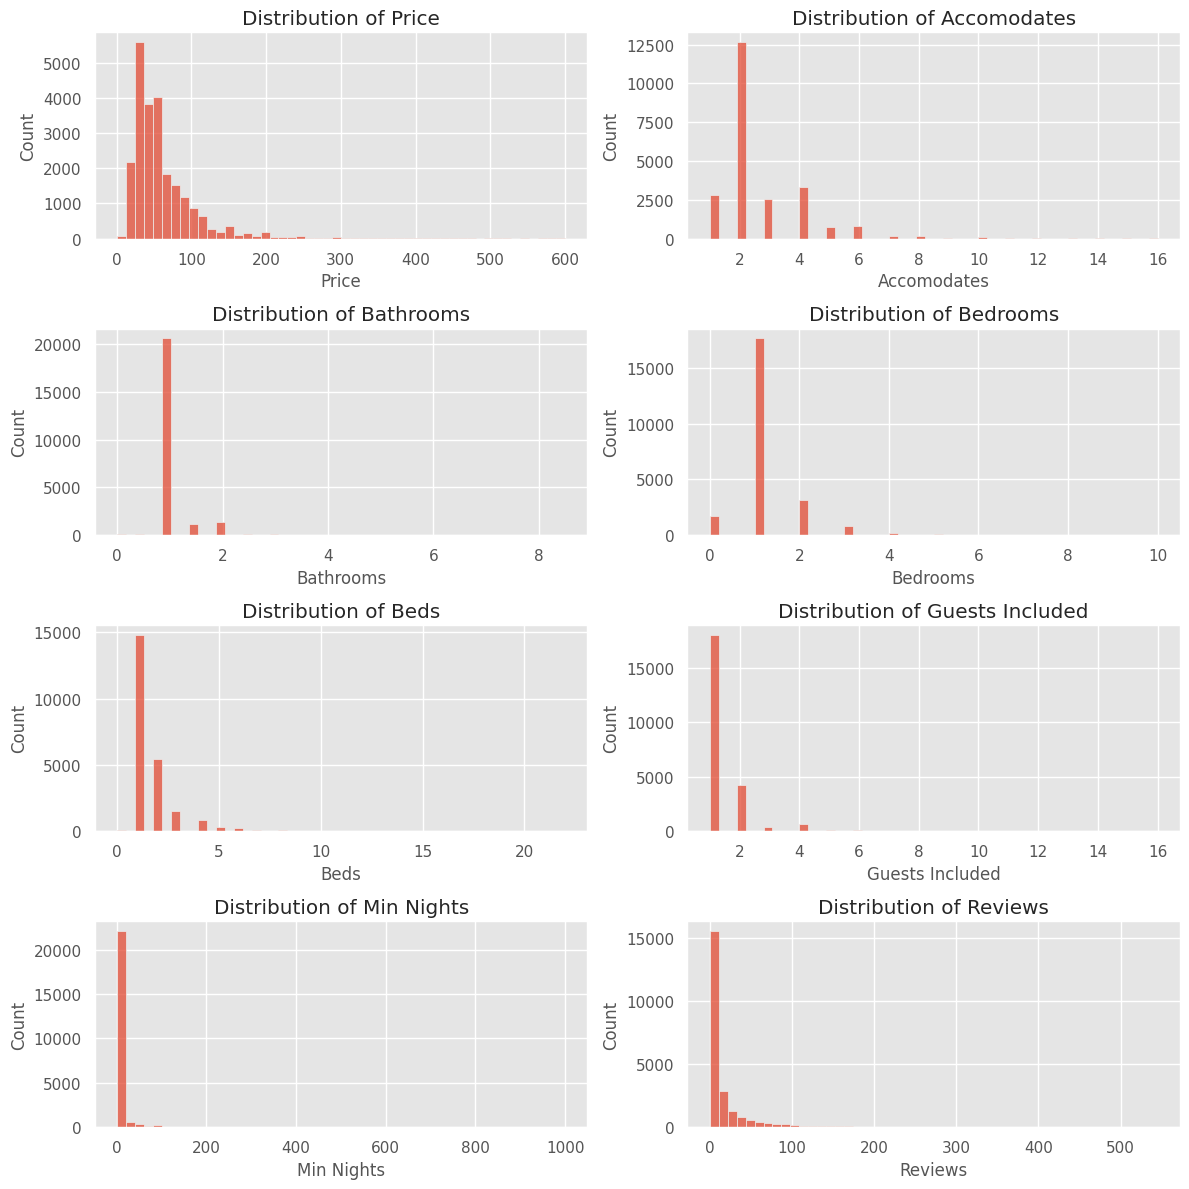

In [226]:
# Checking the distribution of key numerical features
plot_histplot_for_columns(df, numerical_columns)

As expected, we can notice that some of the numerics are more categorical data like (for example, Accomadates, Bathrooms and Beds).
It worth using barplot to show relations ship with target value

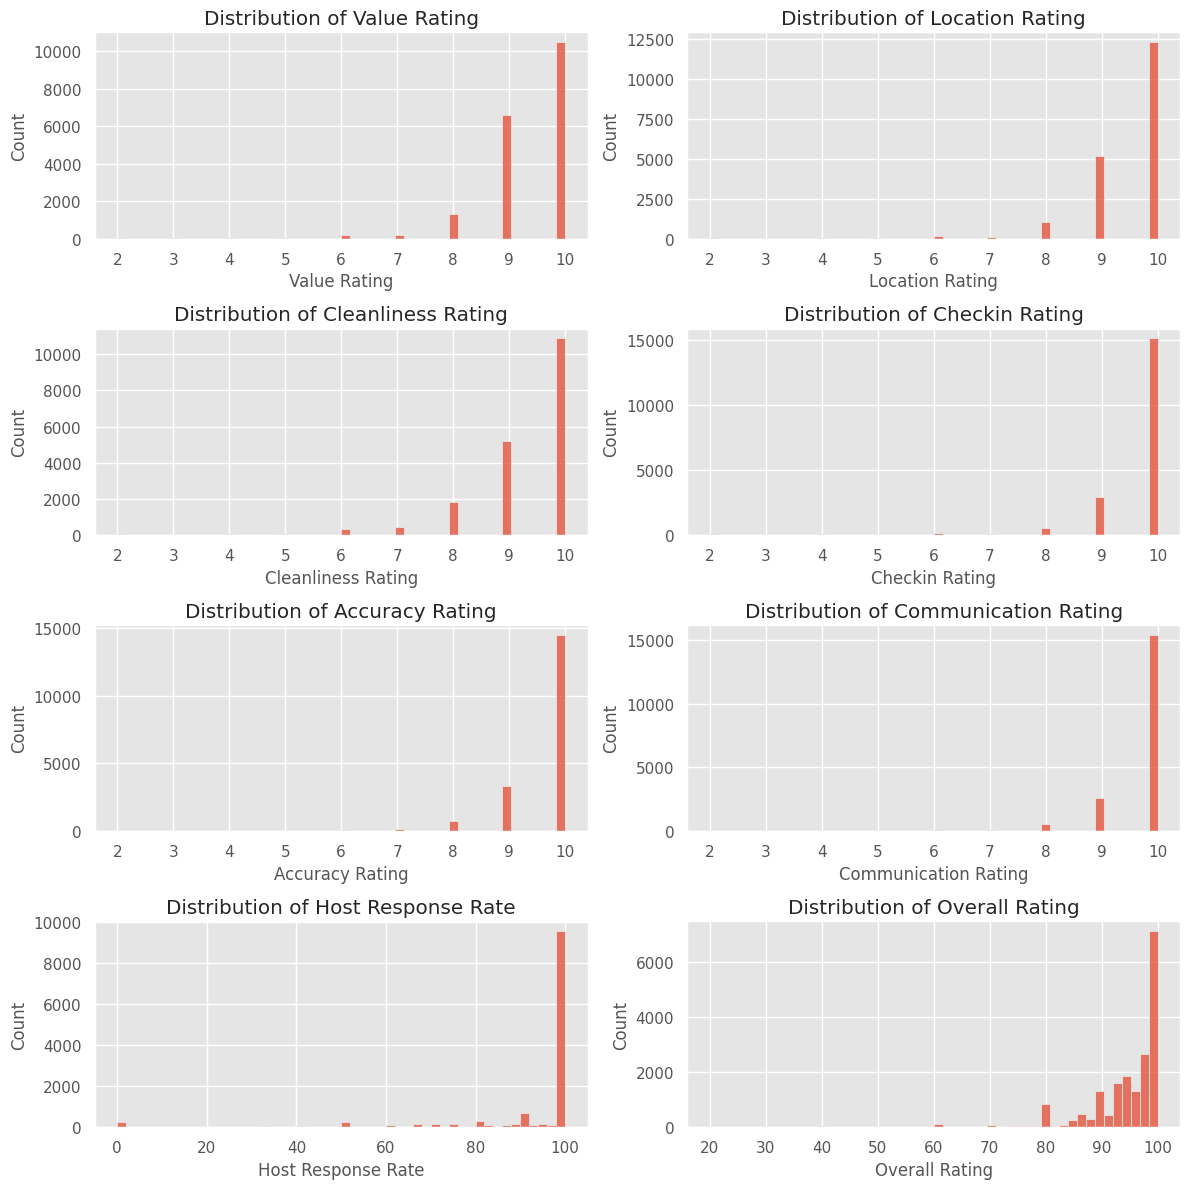

In [227]:
plot_histplot_for_columns(df, rating_columns)

### Bars for continues numbers

In [228]:
categorical_columns

['Room Type',
 'Property Type Reduced',
 'Neighborhood Group',
 'Postal Code Reduced',
 'Host Response Time']

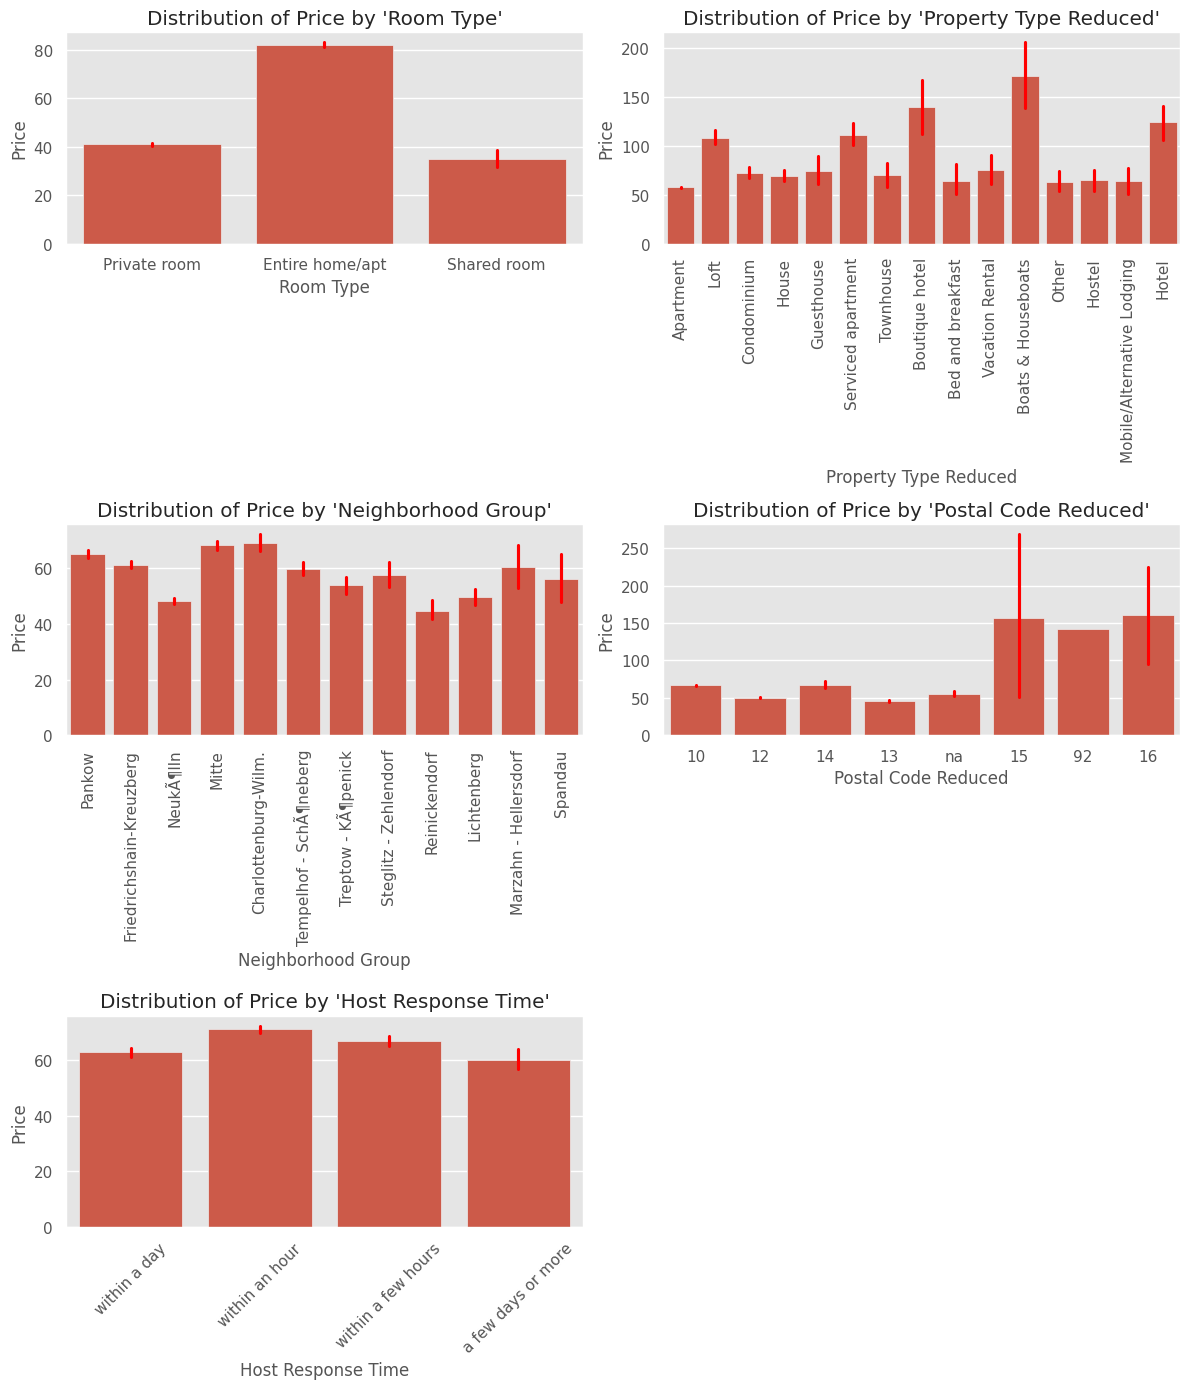

In [229]:
xticks_map = {'Room Type':0, 'Property Type Reduced':90, 'Neighborhood Group':90, 'Neighbourhood Grouped':90, 'Postal Code Reduced':0, 'Host Response Time':45}
plt.figure(figsize=(12, 14))
plt.subplots_adjust(hspace = 0.5)
for i, col in enumerate(categorical_columns, 1):
  plt.subplot(3, 2, i)
  sns.barplot(x=df[col], y=df['Price'], errcolor="red")
  plt.xticks(rotation=xticks_map.get(col))
  plt.title(f"Distribution of Price by '{col}'")

plt.tight_layout()
plt.show()

In [230]:
df['Room Type'].value_counts()

,count
Room Type,
Private room,11658
Entire home/apt,11491
Shared room,311


<Axes: xlabel='Price', ylabel='Count'>

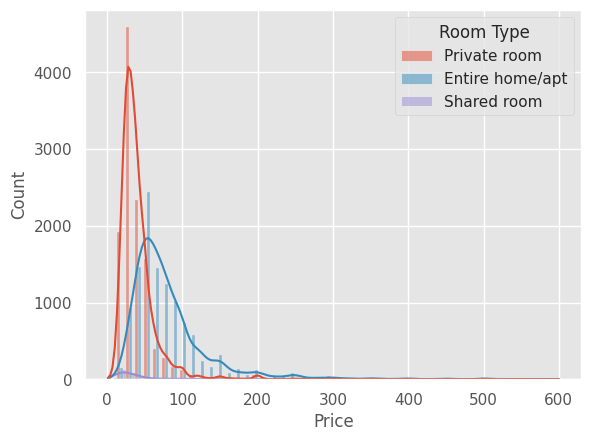

In [231]:
# sns.histplot(data = df[df['Room Type'] == 'Private room'], x="Price", bins=50, kde=True)
sns.histplot(data = df, x="Price", bins=50, hue="Room Type", kde=True, multiple="dodge")

In [232]:
boolean_columns

['Is Superhost', 'Is Exact Location', 'Instant Bookable']

<Axes: xlabel='Price', ylabel='Count'>

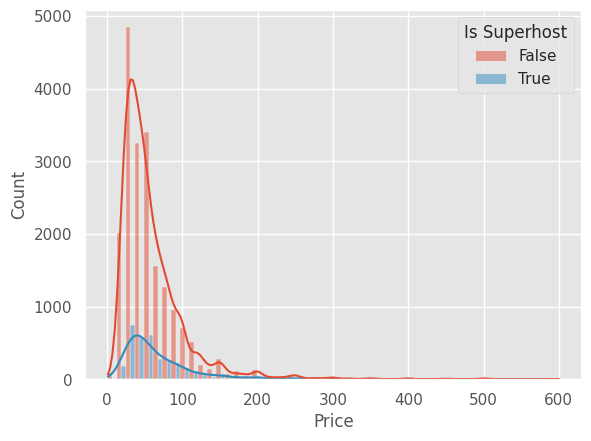

In [233]:
sns.histplot(data = df, x="Price", bins=50, hue="Is Superhost", kde=True, multiple="dodge")

<Axes: xlabel='Price', ylabel='Count'>

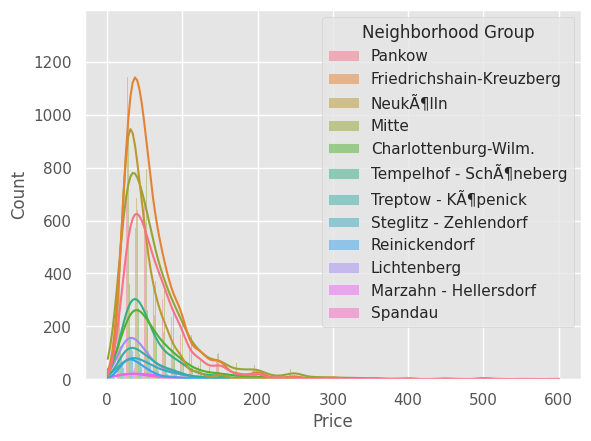

In [234]:
sns.histplot(data = df, x="Price", bins=50, hue="Neighborhood Group", kde=True, multiple="dodge")

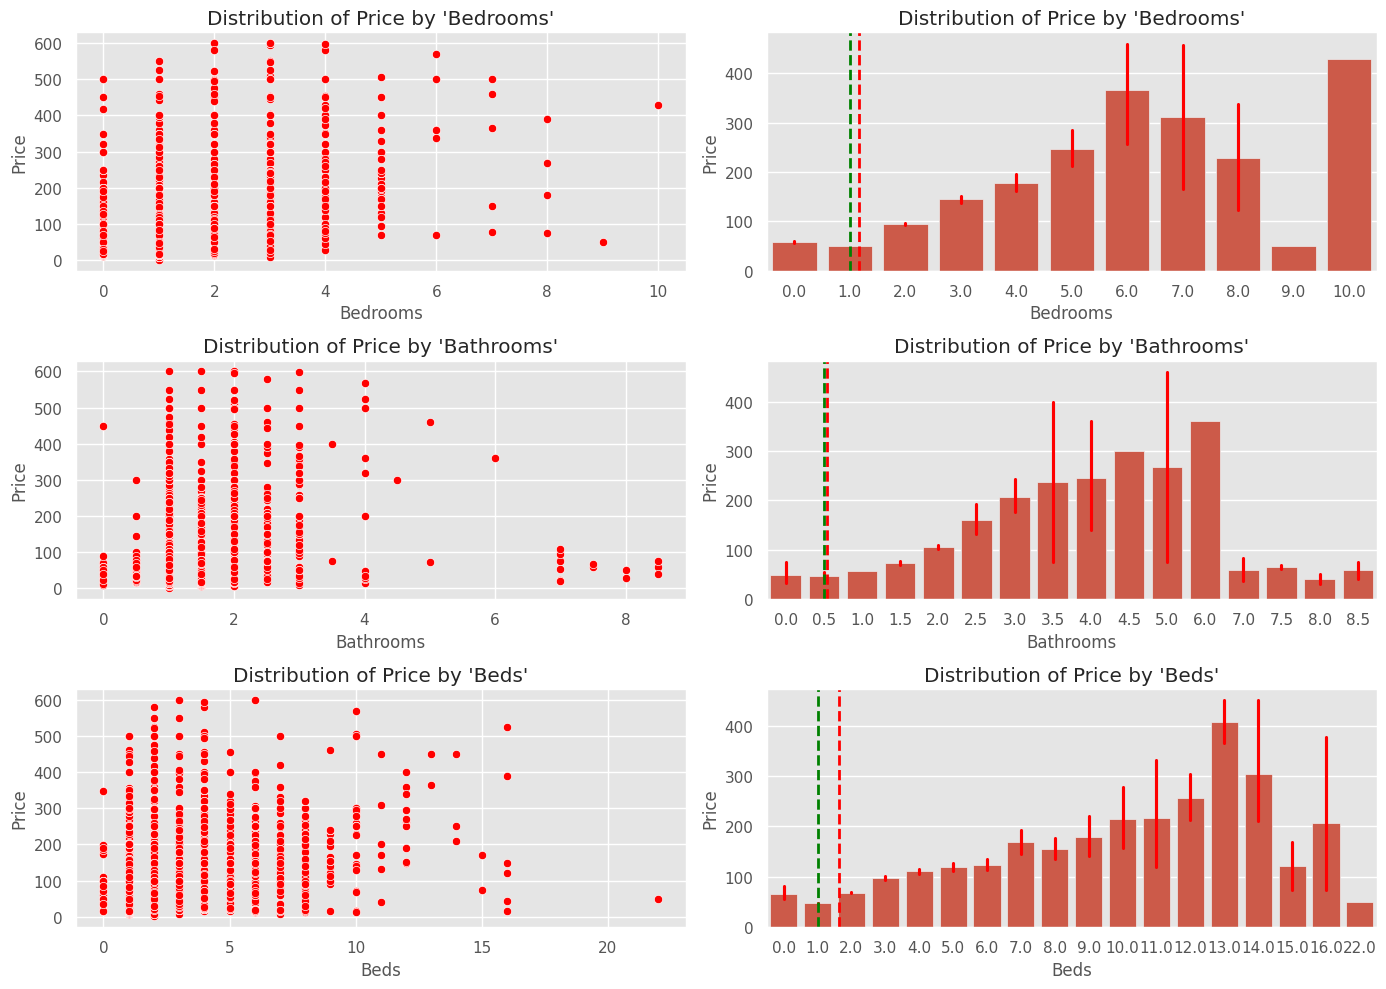

In [235]:
bar_plot_columns = ['Bedrooms', 'Bathrooms', 'Beds']
plt.figure(figsize=(14, 10))
plt.subplots_adjust(hspace = 0.5)
i = 1
for col in bar_plot_columns:
  plt.subplot(3, 2, i)
  sns.scatterplot(x=df[col], y=df['Price'], color='red')
  plt.title(f"Distribution of Price by '{col}'")

  plt.subplot(3, 2, i+1)
  sns.barplot(x=df[col], y=df['Price'], errcolor="red")
  plt.title(f"Distribution of Price by '{col}'")
  plt.axvline(df[col].mean(), color='red', linestyle='dashed', linewidth=2)
  plt.axvline(df[col].median(), color='green', linestyle='dashed', linewidth=2)

  i = i + 2
plt.tight_layout()
plt.show()

## Skewness

In [236]:
def highlight(cell_value):
    highlight = 'background-color: mediumspringgreen;'
    default = ''
    negative = 'background-color: hotpink;'
    if cell_value > 1:
        return highlight
    elif cell_value < -1:
        return negative
    #else
       # return default

numericals = numerical_columns + rating_columns
pd.DataFrame(df[numericals].skew(),columns=['skewness']).sort_values(by='skewness', ascending=False).style.applymap(highlight)

,skewness
Min Nights,21.506775
Bathrooms,6.738902
Guests Included,5.068270
Reviews,4.345326
Price,3.714219
Beds,3.598453
Accomodates,2.563539
Bedrooms,2.113660
Cleanliness Rating,-2.470840
Location Rating,-2.602092


## Checking correlations among numerical features

In [237]:
from sklearn.preprocessing import LabelEncoder

df['Host Since'] = pd.to_datetime(df['Host Since'])
df['Host Since Year'] = df['Host Since'].dt.year

correlation_matrix_df = df.select_dtypes(include=['number'])
correlation_matrix_df = correlation_matrix_df.drop(columns=['Listing ID'], inplace=False)

le = LabelEncoder()
for col in categorical_columns:
  correlation_matrix_df[col] = le.fit_transform(df[col])

correlation_matrix = correlation_matrix_df.corr(method = 'spearman')
correlation_matrix

,Accomodates,Accuracy Rating,Bathrooms,Bedrooms,Beds,Checkin Rating,Cleanliness Rating,Communication Rating,Guests Included,Host Response Rate,Latitude,Location Rating,Longitude,Min Nights,Overall Rating,Price,Reviews,Value Rating,Host Since Year,Room Type,Property Type Reduced,Neighborhood Group,Postal Code Reduced,Host Response Time
Accomodates,1.000000,-0.068347,0.156795,0.506295,0.718838,-0.040509,-0.025764,-0.046071,0.448686,0.049720,0.040085,-0.051158,-0.018343,0.008038,-0.089425,0.536043,0.144479,-0.143921,-0.048456,-0.459367,0.097283,0.010388,-0.045555,-0.091123
Accuracy Rating,-0.068347,1.000000,0.006310,-0.015107,-0.094385,0.421688,0.439086,0.452027,-0.019735,0.067496,-0.010288,0.277268,0.007996,0.051160,0.504682,0.013267,0.020380,0.466973,-0.014117,0.003075,-0.016254,0.023385,0.003656,-0.021792
Bathrooms,0.156795,0.006310,1.000000,0.246021,0.181533,0.011782,0.006486,0.012124,0.090540,0.025502,0.002502,0.019550,-0.038940,0.034927,0.025882,0.134860,0.003685,0.006448,-0.015393,-0.007959,0.108463,-0.005159,-0.020376,-0.029129
Bedrooms,0.506295,-0.015107,0.246021,1.000000,0.526431,0.000829,0.024164,0.000601,0.267628,0.035641,0.004600,-0.020243,-0.010791,0.071826,0.002468,0.342409,0.041620,-0.035033,-0.067891,-0.227725,0.028483,0.028240,0.003581,-0.036816
Beds,0.718838,-0.094385,0.181533,0.526431,1.000000,-0.045640,-0.029026,-0.062302,0.372478,0.039136,0.028584,-0.071736,-0.036266,0.041228,-0.096480,0.414697,0.092888,-0.137571,-0.034733,-0.352985,0.134705,0.023762,-0.017760,-0.087497
Checkin Rating,-0.040509,0.421688,0.011782,0.000829,-0.045640,1.000000,0.315407,0.530897,-0.008495,0.073366,-0.024226,0.233876,0.003390,0.017417,0.383175,0.013840,0.006039,0.346310,-0.006588,0.020630,0.016520,0.023201,0.021725,-0.022635
Cleanliness Rating,-0.025764,0.439086,0.006486,0.024164,-0.029026,0.315407,1.000000,0.336250,0.019746,0.104863,0.005036,0.217219,-0.012711,0.012808,0.536756,0.109701,0.030925,0.414862,-0.019725,-0.044139,0.048289,0.033427,-0.006598,-0.061873
Communication Rating,-0.046071,0.452027,0.012124,0.000601,-0.062302,0.530897,0.336250,1.000000,-0.008040,0.103405,-0.019167,0.254591,0.005967,0.032425,0.428698,0.024043,0.005321,0.370536,-0.029663,0.003264,-0.012157,0.021511,0.011635,-0.025161
Guests Included,0.448686,-0.019735,0.090540,0.267628,0.372478,-0.008495,0.019746,-0.008040,1.000000,0.063555,0.028408,-0.034317,0.003868,0.025692,-0.065424,0.380128,0.207210,-0.102300,-0.080662,-0.321135,0.060535,-0.002998,-0.058054,-0.091449
Host Response Rate,0.049720,0.067496,0.025502,0.035641,0.039136,0.073366,0.104863,0.103405,0.063555,1.000000,0.002746,0.011694,-0.009776,0.003731,0.060043,0.057301,0.126683,0.047651,-0.021736,-0.012031,0.034354,0.014514,0.001600,0.481177


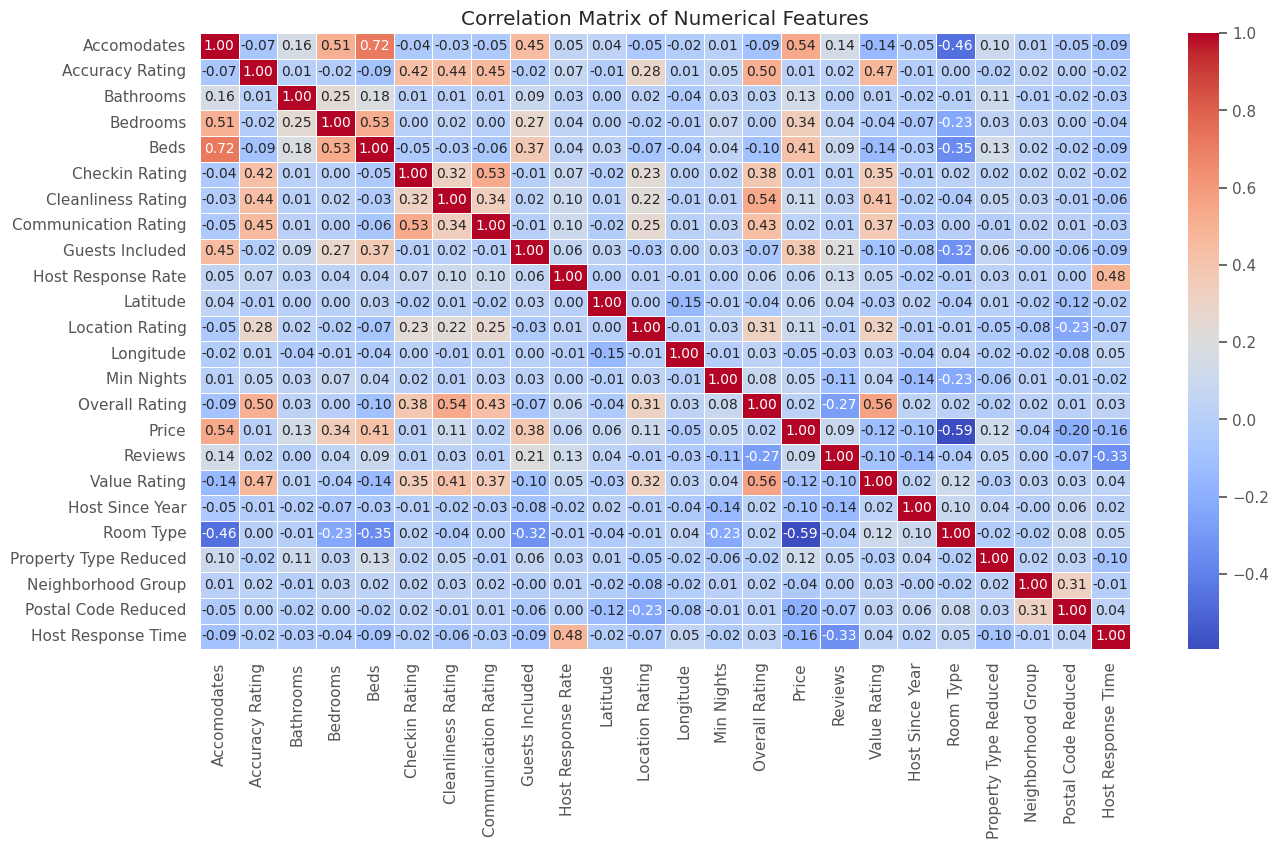

In [238]:
plt.figure(figsize=(15, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

## Outliers

In [239]:
nonn_dummy = numerical_columns + rating_columns
df[nonn_dummy].describe().loc[['min', '25%', '50%', '75%', 'max']].T

,min,25%,50%,75%,max
Price,1.0,31.0,49.0,74.0,600.0
Accomodates,1.0,2.0,2.0,3.0,16.0
Bathrooms,0.0,1.0,1.0,1.0,8.5
Bedrooms,0.0,1.0,1.0,1.0,10.0
Beds,0.0,1.0,1.0,2.0,22.0
Guests Included,1.0,1.0,1.0,1.0,16.0
Min Nights,1.0,2.0,3.0,4.0,1000.0
Reviews,0.0,1.0,5.0,17.0,545.0
Value Rating,2.0,9.0,10.0,10.0,10.0
Location Rating,2.0,9.0,10.0,10.0,10.0


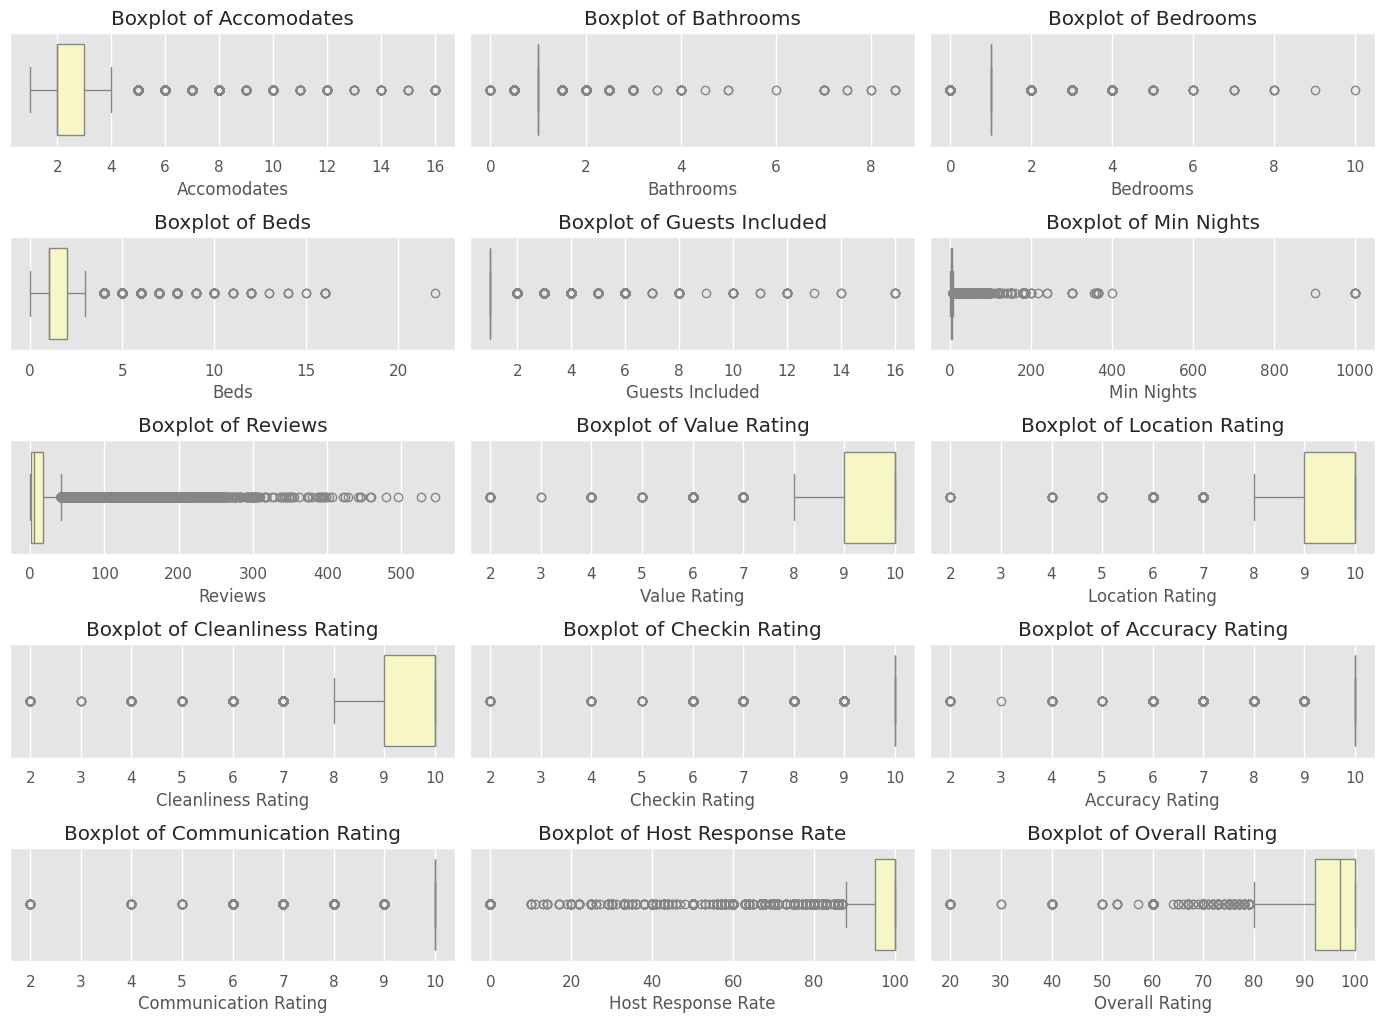

In [240]:
# numericals = numerical_columns + ["Overall Rating", "Host Response Rate"]

plt.figure(figsize=(14, 20))
for i, col in enumerate([c for c in nonn_dummy if c != 'Price'], 1):
    plt.subplot(10, 3, i)
    sns.boxplot(x=df[col].dropna(), palette="Spectral")
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

The boxplots reveal potential outliers in several numerical features, particularly:

1. Price: Likely contains extreme values (high-end listings or pricing errors).
2. Reviews: Some listings have significantly higher review counts than others.
3. Bedrooms, Bathrooms, Beds, Accommodates: Some properties might have unrealistic values (e.g., too many or too few bedrooms relative to accommodations).

## Save state

In [241]:
df.to_pickle("/content/drive/My Drive/Airbnb/df_EDA2.pkl")
df.to_csv("/content/drive/My Drive/Airbnb/df_EDA2.csv")

In [242]:
# cleaned_df = pd.read_pickle('/content/drive/My Drive/Airbnb/df_EDA2.pkl')
# cleaned_df.info()